In [57]:
from sklearn import datasets
import pandas as pd
from matplotlib import pyplot  as plt

In [5]:
breast_cancel_data = datasets.load_breast_cancer()
breast_cancel_data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [9]:
data = pd.DataFrame(data=breast_cancel_data.data, columns=breast_cancel_data.feature_names)

In [10]:
data['target'] = breast_cancel_data.target

In [15]:
data['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [16]:
data.isna().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [17]:
data.dtypes

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

In [18]:
from sklearn.model_selection import train_test_split

In [20]:
x = data.drop('target', axis=1)

In [22]:
y = data['target']

In [98]:
X_train,X_test,y_train,y_test = train_test_split(x,y, test_size=0.20, random_state=12, shuffle=True, stratify=y)

In [34]:
print("Training Samples:", X_train.shape,y_train.shape)
print("Test Samples:", X_test.shape,y_test.shape)

Training Samples: (455, 30) (455,)
Test Samples: (114, 30) (114,)


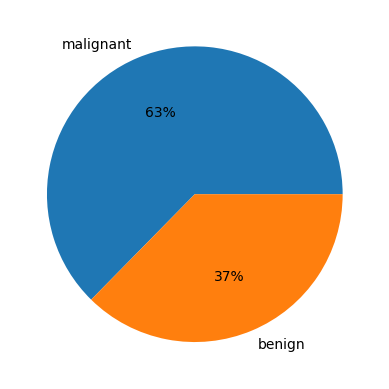

In [99]:
plt.pie(x = y_train.value_counts(), labels= ['malignant', 'benign'], autopct='%1.0f%%')
plt.show()

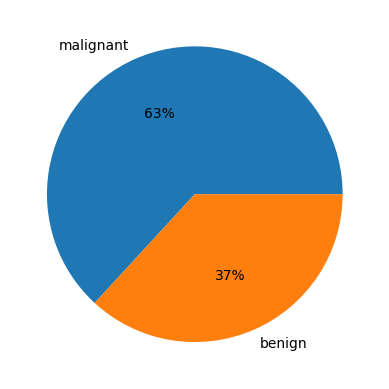

In [69]:
plt.pie(x = y_test.value_counts(), labels= ['malignant', 'benign'], autopct='%1.0f%%')
plt.show()

In [ ]:
MODEL Training

In [100]:
from sklearn.tree import DecisionTreeClassifier


In [101]:
%%time

dt_model = DecisionTreeClassifier(max_depth= 3, class_weight={0:2,1:1})
dt_model.fit(X_train, y_train)

CPU times: total: 15.6 ms
Wall time: 20.7 ms


,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,"{0: 2, 1: 1}"


In [49]:
y_pred_train = dt_model.predict(x_train)

In [93]:
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       170
           1       0.99      0.97      0.98       285

    accuracy                           0.98       455
   macro avg       0.97      0.98      0.98       455
weighted avg       0.98      0.98      0.98       455



In [51]:
y_pred = dt_model.predict(X_test)

In [52]:
from sklearn.metrics import confusion_matrix,classification_report

In [92]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87        42
           1       0.94      0.90      0.92        72

    accuracy                           0.90       114
   macro avg       0.89      0.90      0.90       114
weighted avg       0.91      0.90      0.90       114



In [102]:
from sklearn.preprocessing import StandardScaler

In [103]:
std_scalar = StandardScaler()

In [104]:
scaled_x = pd.DataFrame(std_scalar.fit_transform(x), columns= breast_cancel_data.feature_names)
scaled_x

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.110995,0.721473,2.060786,2.343856,1.041842,0.219060,1.947285,2.320965,-0.312589,-0.931027,...,1.901185,0.117700,1.752563,2.015301,0.378365,-0.273318,0.664512,1.629151,-1.360158,-0.709091
565,1.704854,2.085134,1.615931,1.723842,0.102458,-0.017833,0.693043,1.263669,-0.217664,-1.058611,...,1.536720,2.047399,1.421940,1.494959,-0.691230,-0.394820,0.236573,0.733827,-0.531855,-0.973978
566,0.702284,2.045574,0.672676,0.577953,-0.840484,-0.038680,0.046588,0.105777,-0.809117,-0.895587,...,0.561361,1.374854,0.579001,0.427906,-0.809587,0.350735,0.326767,0.414069,-1.104549,-0.318409
567,1.838341,2.336457,1.982524,1.735218,1.525767,3.272144,3.296944,2.658866,2.137194,1.043695,...,1.961239,2.237926,2.303601,1.653171,1.430427,3.904848,3.197605,2.289985,1.919083,2.219635


In [110]:
x_train,x_test,y_train,y_test = train_test_split(scaled_x, y, test_size=0.20, random_state=12, shuffle=True, stratify=y)

In [107]:
print("Training Samples:", X_train.shape,y_train.shape)
print("Test Samples:", X_test.shape,y_test.shape)

Training Samples: (455, 30) (455,)
Test Samples: (114, 30) (114,)


In [111]:
%%time

dt_model = DecisionTreeClassifier(max_depth= 3, class_weight={0:2,1:1})
dt_model.fit(x_train, y_train)

CPU times: total: 15.6 ms
Wall time: 33.6 ms


,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,"{0: 2, 1: 1}"


In [94]:
from pickle import dump

In [95]:
dump(scaled_x, open('data_transform.pkl', 'wb'))

In [ ]:
dump(dt_model, open('dt_model.pkl', 'wb'))